# Survey Analysis: Software Engineering in the Era of Generative AI
**Survey conducted among ICT professionals in the Rotterdam area, Netherlands (July–November 2025)**  
**Purpose:** Understand skill requirements for future software developers in the era of generative AI, to inform curriculum design at Dutch Universities of Applied Sciences (HBO).

In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import textwrap
from collections import Counter
from scipy.stats import chisquare, fisher_exact, mannwhitneyu

In [2]:
# Cell 2 — Configuration and Constants

FILE_PATH = "./data/Survey_SoftwareDevelopmentInEraGenAI_polished.xlsx"
SHEETS = {}

# Visual style
BG_COLOR        = "#F7F9FC"
TITLE_COLOR     = "#2C3E50"
FOOTNOTE_COLOR  = "#7F8C8D"
GRID_COLOR      = "#D5DCE8"
SPINE_COLOR     = "#C0C8D4"
AXIS_LBL_COLOR  = "#5A6475"
PALETTE = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3",
    "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD"
]

# Scale definitions
SCALE_USEFULNESS = {
    "order":  ["Not Useful", "Somewhat Useful", "Very Useful", "Essential"],
    "na":     "Not Applicable",
    "colors": ["#C44E52", "#DD8452", "#4C72B0", "#2A6099"],
}

SCALE_IMPORTANCE_CHANGE = {
    "order":  ["Decreasing in Importance", "No Change", "Slightly Increasing", "Strongly Increasing"],
    "na":     None,
    "colors": ["#C44E52", "#8C8C8C", "#55A868", "#2A6099"],
}

# Question registry
QUESTION_REGISTRY = {
    "Q01": {"type": "multi",   "label": "Primary role in software development"},
    "Q02": {"type": "single",  "label": "Years of experience",
            "order": ["< 1 year", "1 - 3 years", "4 - 6 years", "7 - 10 years", "> 10 years"]},
    "Q03": {"type": "single",  "label": "Organisation size",
            "order": ["Startup (1-10 employees)", "Small (11-50 employees)",
                      "Medium Business (51-100 employees)", "Large Enterprise (100+ employees)"]},
    "Q04": {"type": "multi",   "label": "Primary programming languages"},
    "Q05": {"type": "single",  "label": "Highest education level (Dutch system)"},
    "Q06": {"type": "single",  "label": "Highest academic qualification",
            "order": ["Associate degree", "Bachelor's degree (BSc, BA, etc.)",
                      "Master's degree (MSc, MA, etc.)", "PhD (Doctorate)"]},
    "Q07": {"type": "single",  "label": "Organisation's stance on AI tools"},
    "Q08": {"type": "single",  "label": "Frequency of GenAI tool usage",
            "order": ["Rarely (a few times a month)", "Occasionally (a few times a week)",
                      "Regularly (daily or almost daily)"]},
    "Q09": {"type": "multi",   "label": "Tasks where GenAI is used"},
    "Q10": {"type": "scaling", "label": "Usefulness of GenAI per task",
            "scale": SCALE_USEFULNESS},
    "Q11": {"type": "multi",   "label": "Common issues experienced with GenAI"},
    "Q12": {"type": "single",  "label": "Estimated % of AI-assisted work (5 yrs)",
            "order": ["21% - 40%", "41 % - 60 %", "61 % - 80 %", "More than 80 %"]},
    "Q13": {"type": "multi",   "label": "SDLC phases GenAI will take over"},
    "Q14": {"type": "scaling", "label": "Expected change in skill importance",
            "scale": SCALE_IMPORTANCE_CHANGE},
    "Q16": {"type": "multi",   "label": "Most essential skills for future developers"},
    "Q17": {"type": "multi",   "label": "Main challenges in AI-assisted development"},
    "Q18": {"type": "single",  "label": "Trust in AI-generated code without review",
            "order": ["Not at all", "Somewhat", "Mostly"]},
    "Q19": {"type": "single",  "label": "Will AI replace traditional development roles?"},
    "Q20": {"type": "single",  "label": "AI impact on junior developer learning curve"},
    "Q21": {"type": "open",    "label": "Greatest risk of heavy reliance on AI-generated code"},
    "Q22": {"type": "open",    "label": "How hiring will change with mainstream AI tools"},
    "Q23": {"type": "open",    "label": "Additional comments on AI in software development"},
}

In [3]:
# Cell 3 — Data Loading and Parsing Helpers

def load_data(path):
    """Load all sheets from the Excel file into the global SHEETS dict."""
    raw = pd.read_excel(path, sheet_name=None, header=None)
    SHEETS.update(raw)
    print("Loaded sheets:", list(raw.keys()))
    return raw


def _split_choices(cell_value):
    """Split a semicolon-delimited cell into a clean list, discarding empty strings."""
    if pd.isna(cell_value):
        return []
    return [c.strip() for c in str(cell_value).split(";") if c.strip()]


def _get_responses(qid):
    """Return raw response Series (col 1, rows 2+), dropna, cast to str."""
    sheet = SHEETS[qid]
    return sheet.iloc[1:, 1].dropna().astype(str)


def get_standard_question(qid):
    """Return DataFrame [id, response] for standard (single/open) questions."""
    sheet = SHEETS[qid]
    df = sheet.iloc[1:, :2].copy()
    df.columns = ["id", "response"]
    return df.reset_index(drop=True)


def get_scaling_question(qid):
    """Return DataFrame (id as index, items as columns) for scaling questions."""
    sheet = SHEETS[qid]
    items = [str(c).replace("\xa0", " ").strip() for c in sheet.iloc[1, 1:].tolist()]
    data = sheet.iloc[2:].copy()
    data = data.reset_index(drop=True)
    ids = data.iloc[:, 0]
    values = data.iloc[:, 1:]
    values.columns = items
    values.index = ids.values
    values.index.name = "id"
    return values


def get_multichoice(qid):
    """Extend get_standard_question with a 'choices' column (list of strings)."""
    df = get_standard_question(qid)
    df["choices"] = df["response"].apply(_split_choices)
    return df


def _flat_choices(qid):
    """Return (flat_choices_Series, n_respondents) for multi-choice questions."""
    df = get_multichoice(qid)
    valid = df[df["response"].notna()]
    n_respondents = len(valid)
    all_choices = [choice for choices in valid["choices"] for choice in choices]
    return pd.Series(all_choices), n_respondents


# Load data immediately
load_data(FILE_PATH)

Loaded sheets: ['complete', 'Q01', 'Q02', 'Q03', 'Q04', 'Q05', 'Q06', 'Q07', 'Q08', 'Q09', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23']


{'complete':     0                    1                    2          3     4   \
 0   ID           Start time      Completion time      Email  Name   
 1    2  2025-07-17 13:59:03  2025-07-17 14:13:46  anonymous   NaN   
 2    3  2025-07-17 14:16:58  2025-07-17 14:25:16  anonymous   NaN   
 3    4  2025-07-17 14:14:34  2025-07-17 14:26:17  anonymous   NaN   
 4    5  2025-07-17 14:14:22  2025-07-17 14:28:01  anonymous   NaN   
 5    6  2025-07-17 14:20:06  2025-07-17 14:34:32  anonymous   NaN   
 6    7  2025-07-17 14:46:54  2025-07-17 14:54:39  anonymous   NaN   
 7    8  2025-07-17 15:13:39  2025-07-17 15:33:20  anonymous   NaN   
 8    9  2025-07-17 17:24:47  2025-07-17 17:27:20  anonymous   NaN   
 9   10  2025-07-17 22:11:20  2025-07-17 22:15:37  anonymous   NaN   
 10  11  2025-07-18 08:30:16  2025-07-18 08:42:16  anonymous   NaN   
 11  12  2025-07-18 09:09:36  2025-07-18 09:26:04  anonymous   NaN   
 12  13  2025-07-18 13:16:24  2025-07-18 13:36:40  anonymous   NaN   
 13  14 

In [4]:
# Cell 4 — Validation

def validate(sheets):
    """Run data extraction checks and print PASS / FAIL per check."""
    results = []

    def _check(label, actual, expected):
        passed = actual == expected
        status = "PASS" if passed else "FAIL"
        print(f"[{status}]  {label}")
        if not passed:
            print(f"        Expected : {expected}")
            print(f"        Got      : {actual}")
        results.append(passed)

    print("=" * 60)
    print("VALIDATION")  
    print("=" * 60)

    # Q10 scaling — id=3
    q10 = get_scaling_question("Q10")
    row3 = q10.loc[3] if 3 in q10.index else None
    if row3 is not None:
        _check("Q10 id=3  Brainstorming",           str(row3["Brainstorming"]),                   "Somewhat Useful")
        _check("Q10 id=3  Code generation",         str(row3["Code generation / auto-completion"]),"Very Useful")
        _check("Q10 id=3  Code Documentation",      str(row3["Code Documentation"]),              "Very Useful")
        _check("Q10 id=3  Debugging (N/A)",         str(row3["Debugging / Error Explanation"]),   "Not Applicable")
    else:
        print("[FAIL]  Q10 id=3 not found")

    # Q10 scaling — id=24
    row24 = q10.loc[24] if 24 in q10.index else None
    if row24 is not None:
        _check("Q10 id=24 Brainstorming",           str(row24["Brainstorming"]),                   "Very Useful")
        _check("Q10 id=24 Code generation",         str(row24["Code generation / auto-completion"]),"Essential")
        # All others should be NaN (blank)
        other_items = [c for c in q10.columns if c not in ["Brainstorming", "Code generation / auto-completion"]]
        all_blank = all(pd.isna(row24[c]) for c in other_items)
        _check("Q10 id=24 all others blank",        all_blank, True)
    else:
        print("[FAIL]  Q10 id=24 not found")

    # Q08 — id=2
    q08 = get_standard_question("Q08")
    r08 = q08[q08["id"] == 2]
    actual_q08 = r08["response"].values[0] if not r08.empty else None
    _check("Q08 id=2", actual_q08, "Regularly (daily or almost daily)")

    # Q23 — id=6  (open; check key phrases)
    q23 = get_standard_question("Q23")
    r23 = q23[q23["id"] == 6]
    actual_q23 = r23["response"].values[0] if not r23.empty else ""
    contains_lowcode    = "Low-Code" in str(actual_q23)
    contains_context_eng = "Context Engineering" in str(actual_q23)
    _check("Q23 id=6  contains 'Low-Code'",           contains_lowcode,     True)
    _check("Q23 id=6  contains 'Context Engineering'", contains_context_eng, True)

    # Q16 multi-choice — id=14
    q16 = get_multichoice("Q16")
    r16 = q16[q16["id"] == 14]
    actual_choices = sorted(r16["choices"].values[0]) if not r16.empty else []
    expected_choices = sorted([
        "Critical thinking and code review skills",
        "Secure coding and ethical AI awareness",
        "Data privacy and regulatory compliance awareness",
    ])
    _check("Q16 id=14 multi-choice (3 choices)", actual_choices, expected_choices)

    print("=" * 60)
    n_pass = sum(results)
    n_total = len(results)
    print(f"Result: {n_pass}/{n_total} checks passed")
    print("=" * 60)


validate(SHEETS)

VALIDATION
[PASS]  Q10 id=3  Brainstorming
[PASS]  Q10 id=3  Code generation
[PASS]  Q10 id=3  Code Documentation
[PASS]  Q10 id=3  Debugging (N/A)
[PASS]  Q10 id=24 Brainstorming
[PASS]  Q10 id=24 Code generation
[PASS]  Q10 id=24 all others blank
[PASS]  Q08 id=2
[PASS]  Q23 id=6  contains 'Low-Code'
[PASS]  Q23 id=6  contains 'Context Engineering'
[PASS]  Q16 id=14 multi-choice (3 choices)
Result: 11/11 checks passed


In [5]:
# Cell 5 — Statistical Analysis Helpers (private)

def _wilson_ci(n_success, n_total, z=1.96):
    """Wilson score 95% CI. Returns (lower, upper). Handles n_total=0."""
    if n_total == 0:
        return (0.0, 0.0)
    p = n_success / n_total
    denom = 1 + z**2 / n_total
    centre = (p + z**2 / (2 * n_total)) / denom
    margin = (z * np.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2))) / denom
    return (max(0.0, centre - margin), min(1.0, centre + margin))


def _shannon_entropy(counts_array):
    """Shannon entropy. Returns (entropy_bits, normalised_entropy) where 0=full consensus, 1=uniform."""
    counts = np.array([c for c in counts_array if c > 0], dtype=float)
    if len(counts) == 0:
        return (0.0, 0.0)
    probs = counts / counts.sum()
    entropy_bits = -np.sum(probs * np.log2(probs))
    max_entropy = np.log2(len(counts))
    normalised = entropy_bits / max_entropy if max_entropy > 0 else 0.0
    return (entropy_bits, normalised)


def _chi2_uniform(counts_array):
    """Chi-squared goodness-of-fit vs uniform. Returns (stat, p) or (None, None) if <2 categories."""
    counts = np.array([c for c in counts_array if c > 0], dtype=float)
    if len(counts) < 2:
        return (None, None)
    stat, p = chisquare(counts)
    return (stat, p)


def _ordinal_stats(values_series, scale_map, n_boot=2000, seed=42):
    """Map labels to ordinal scores; return dict with n, mean, std, median, mean_ci_95."""
    scores = values_series.map(scale_map).dropna()
    if len(scores) == 0:
        return {"n": 0, "mean": np.nan, "std": np.nan, "median": np.nan, "mean_ci_95": (np.nan, np.nan)}
    rng = np.random.default_rng(seed)
    boot_means = [rng.choice(scores.values, size=len(scores), replace=True).mean() for _ in range(n_boot)]
    ci = (np.percentile(boot_means, 2.5), np.percentile(boot_means, 97.5))
    return {
        "n":          len(scores),
        "mean":       scores.mean(),
        "std":        scores.std(),
        "median":     scores.median(),
        "mean_ci_95": ci,
    }

In [6]:
# Cell 6 — Statistical Analysis: Public Function and Report Printers

def _print_separator(width=74, char="\u2500"):
    print(char * width)


def _print_categorical_report(results):
    """Print table: category | n | % | 95% CI; dominant, entropy, chi2."""
    print(f"\nQ{results['qid']}  |  {results['question']}")
    _print_separator()
    header = f"  {'Category':<45}  {'n':>5}  {'%':>6}  {'95% CI':>15}"
    print(header)
    _print_separator(char="-")
    for cat, n, pct, (lo, hi) in zip(
            results["categories"], results["counts"],
            results["pcts"], results["wilson_cis"]):
        ci_str = f"[{lo*100:.1f}%, {hi*100:.1f}%]"
        print(f"  {cat:<45}  {n:>5}  {pct*100:>5.1f}%  {ci_str:>15}")
    _print_separator()
    print(f"  Dominant category : {results['dominant']}")
    ent_b, ent_n = results["entropy"]
    print(f"  Shannon entropy   : {ent_b:.4f} bits  (normalised: {ent_n:.4f})")
    chi2, p = results["chi2"]
    if chi2 is not None:
        sig = "\u2713 significant" if p < 0.05 else "\u2717 not significant"
        print(f"  \u03c7\u00b2 (uniform)      : {chi2:.4f},  p = {p:.4f}  \u2014  {sig} at \u03b1 = 0.05")
    print()


def _print_scaling_report(results):
    """Per-item: distribution, ordinal stats, positive%, entropy, N/A count."""
    print(f"\nQ{results['qid']}  |  {results['question']}")
    _print_separator()
    for item_result in results["items"]:
        item = item_result["item"]
        stats = item_result["stats"]
        print(f"  Item: {item}")
        for lvl, n, pct in zip(item_result["levels"], item_result["counts"], item_result["pcts"]):
            print(f"    {lvl:<30} : {n:>4}  ({pct*100:.1f}%)")
        print(f"    N/A count : {item_result['na_count']}")
        print(f"    Positive% : {item_result['positive_pct']*100:.1f}%  "
              f"| Dominant: {item_result['dominant']}")
        print(f"    Mean: {stats['mean']:.3f}  Median: {stats['median']:.1f}  "
              f"Std: {stats['std']:.3f}")
        ent_b, ent_n = item_result["entropy"]
        print(f"    Entropy: {ent_b:.4f} bits  (norm: {ent_n:.4f})")
        _print_separator(char="-")
    print()


def analyse_question(sheets, qid, question_type, *,
                     top_n=None, scale=None, na_label=None,
                     print_report=True, return_results=False):
    """
    Analyse a single question.
    - 'single'/'multi': counts, proportions, Wilson CI, dominant, Shannon entropy, chi2 uniform.
    - 'scaling': per item — counts, proportions, dominant, positive%, Shannon entropy, ordinal stats, N/A count.
    Returns dict if return_results=True, else None.
    """
    sheet = sheets[qid]
    question_text = str(sheet.iloc[0, 1]) if question_type != "scaling" else str(sheet.iloc[0, 0])

    if question_type in ("single", "multi", "open"):
        if question_type == "multi":
            flat, n_respondents = _flat_choices(qid)
            counter = Counter(flat)
        else:
            responses = _get_responses(qid)
            counter = Counter(responses)
            n_respondents = len(responses)

        if top_n:
            items = counter.most_common(top_n)
        else:
            items = list(counter.items())

        categories = [i[0] for i in items]
        counts     = [i[1] for i in items]
        total      = n_respondents
        pcts       = [c / total for c in counts]
        wilson_cis = [_wilson_ci(c, total) for c in counts]
        dominant   = categories[counts.index(max(counts))] if counts else None
        entropy    = _shannon_entropy(counts)
        chi2       = _chi2_uniform(counts)

        res = {
            "qid": qid, "question": question_text, "type": question_type,
            "n": total, "categories": categories, "counts": counts,
            "pcts": pcts, "wilson_cis": wilson_cis,
            "dominant": dominant, "entropy": entropy, "chi2": chi2,
        }
        if print_report and question_type != "open":
            _print_categorical_report(res)
        return res if return_results else None

    elif question_type == "scaling":
        scale_order  = scale["order"]
        scale_na     = scale.get("na") or na_label
        scale_map    = {lvl: i + 1 for i, lvl in enumerate(scale_order)}
        df           = get_scaling_question(qid)
        question_text = str(sheet.iloc[0, 1]) if sheet.shape[1] > 1 else qid

        item_results = []
        for item in df.columns:
            col      = df[item]
            na_count = int((col == scale_na).sum()) if scale_na else 0
            filtered = col[col != scale_na].dropna() if scale_na else col.dropna()
            counts   = [int((filtered == lvl).sum()) for lvl in scale_order]
            total    = sum(counts)
            pcts     = [c / total if total > 0 else 0.0 for c in counts]
            pos_idx  = len(scale_order) - 2  # top-2 positive
            pos_pct  = sum(pcts[pos_idx:])
            dominant = scale_order[counts.index(max(counts))] if total > 0 else None
            entropy  = _shannon_entropy(counts)
            stats    = _ordinal_stats(filtered, scale_map)
            item_results.append({
                "item": item, "levels": scale_order, "counts": counts, "pcts": pcts,
                "na_count": na_count, "positive_pct": pos_pct, "dominant": dominant,
                "entropy": entropy, "stats": stats,
            })

        res = {"qid": qid, "question": question_text, "type": "scaling", "items": item_results}
        if print_report:
            _print_scaling_report(res)
        return res if return_results else None

In [7]:
# Cell 7 — Visualisation Helpers (private)

def _fig_setup(figsize=(10, 5)):
    """Create figure and single axes with BG_COLOR background."""
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(BG_COLOR)
    return fig, ax


def _style_axes(ax):
    """Remove top/right/left spines, set bottom spine, grid, tick params."""
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(SPINE_COLOR)
    ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.7, linestyle="--")
    ax.yaxis.grid(False)
    ax.tick_params(colors=AXIS_LBL_COLOR, labelsize=9)


def _add_title(ax, qid, question, wrap_width=80):
    """Bold left-aligned title as '{qid}  |  {wrapped question}'."""
    wrapped = textwrap.fill(question, width=wrap_width)
    ax.set_title(f"{qid}  |  {wrapped}", loc="left", fontsize=11,
                 fontweight="bold", color=TITLE_COLOR, pad=12)


def _add_footnote(fig, text):
    """Small grey footnote at bottom-left."""
    fig.text(0.02, 0.01, text, ha="left", va="bottom",
             fontsize=8, color=FOOTNOTE_COLOR, style="italic")


def _save_or_show(fig, save_path=None):
    """Save figure if save_path given, else show. Always close."""
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
    else:
        plt.show()
    plt.close(fig)


def _wrap_labels(labels, width=40):
    """Wrap list of strings; return newline-joined list."""
    return ["\n".join(textwrap.wrap(lbl, width=width)) for lbl in labels]


def _annotate_bar(ax, bar, value, pct, x_max, show_pct=True):
    """Annotate a horizontal bar with '  n  (x%)'."""
    offset = x_max * 0.01
    label = f"  {value}  ({pct*100:.1f}%)" if show_pct else f"  {value}"
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
            label, va="center", ha="left", fontsize=9, color=AXIS_LBL_COLOR)

In [8]:
# Cell 8 — Visualisation: Pie Chart (single-choice)

def plot_pie(sheets, qid, *, order=None, colors=None,
             min_pct_label=3.0, figsize=(8, 5), save_path=None):
    """Pie chart for single-choice questions with legend panel."""
    sheet = sheets[qid]
    question_text = str(sheet.iloc[0, 1])
    responses = _get_responses(qid)
    counter = Counter(responses)

    if order:
        labels = [o for o in order if o in counter]
        labels += [k for k in counter if k not in order]
    else:
        labels = [k for k, _ in sorted(counter.items(), key=lambda x: -x[1])]

    sizes = [counter[lbl] for lbl in labels]
    total = sum(sizes)
    pcts  = [s / total for s in sizes]

    chart_colors = (colors or PALETTE)[:len(labels)]

    fig, ax = _fig_setup(figsize)

    def autopct_fn(pct):
        return f"{pct:.1f}%" if pct >= min_pct_label else ""

    wedges, texts, autotexts = ax.pie(
        sizes, labels=None, colors=chart_colors,
        autopct=autopct_fn, startangle=140,
        wedgeprops=dict(linewidth=0.5, edgecolor="white")
    )
    for at in autotexts:
        at.set_fontsize(8)
        at.set_color("white")

    legend_labels = [f"{lbl}  (n={s}, {p*100:.1f}%)" for lbl, s, p in zip(labels, sizes, pcts)]
    ax.legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1, 0.5),
              fontsize=9, frameon=False)

    _add_title(ax, qid, question_text)
    _add_footnote(fig, f"n = {total} respondents")
    fig.tight_layout()
    _save_or_show(fig, save_path)

In [9]:
# Cell 9 — Visualisation: Horizontal Bar Chart (multi-choice)

def plot_multichoice(sheets, qid, *, order=None, top_n=None, wrap_width=42,
                     show_pct=True, color=None, figsize=(10, 6), save_path=None):
    """Horizontal bar chart for multi-choice questions."""
    sheet = sheets[qid]
    question_text = str(sheet.iloc[0, 1])
    flat, n_respondents = _flat_choices(qid)
    counter = Counter(flat)

    if order:
        labels = [o for o in order if o in counter]
        labels += [k for k in counter if k not in order]
    else:
        labels = [k for k, _ in counter.most_common()]

    if top_n:
        labels = labels[:top_n]

    labels = list(reversed(labels))  # ascending sort (top of chart = most common)
    counts = [counter[lbl] for lbl in labels]
    pcts   = [c / n_respondents for c in counts]
    x_max  = max(counts) * 1.25 if counts else 1

    wrapped = _wrap_labels(labels, width=wrap_width)
    bar_color = color or PALETTE[0]

    fig, ax = _fig_setup(figsize)
    bars = ax.barh(wrapped, counts, color=bar_color, height=0.6,
                   edgecolor="white", linewidth=0.4)

    for bar, val, pct in zip(bars, counts, pcts):
        _annotate_bar(ax, bar, val, pct, x_max, show_pct)

    ax.set_xlim(0, x_max)
    ax.set_xlabel("Number of respondents", fontsize=9, color=AXIS_LBL_COLOR)
    _style_axes(ax)
    _add_title(ax, qid, question_text)
    _add_footnote(fig,
        f"n = {n_respondents} respondents  \u2022  % = share of respondents  \u2022  multiple selections allowed")
    fig.tight_layout()
    _save_or_show(fig, save_path)

In [10]:
# Cell 10 — Visualisation: Stacked Bar Chart (scaling)

def plot_scaling(sheets, qid, scale, *, item_order=None, top_n=None,
                 wrap_width=38, show_na_bar=True, show_counts=True,
                 min_seg_pct=6.0, figsize=(12, 7), save_path=None):
    """100% stacked horizontal bar chart for scaling questions."""
    sheet  = sheets[qid]
    q_text = str(sheet.iloc[0, 1]) if sheet.shape[1] > 1 else qid
    df     = get_scaling_question(qid)
    scale_order = scale["order"]
    scale_na    = scale.get("na")
    colors_map  = dict(zip(scale_order, scale["colors"]))

    items = list(df.columns) if item_order is None else item_order
    if top_n:
        items = items[:top_n]

    # Sort by share of top-2 positive (most positive at top)
    def _pos_share(item):
        col = df[item]
        filtered = col[col != scale_na].dropna() if scale_na else col.dropna()
        total = len(filtered)
        if total == 0:
            return 0.0
        return sum((filtered == lvl).sum() for lvl in scale_order[-2:]) / total

    if item_order is None:
        items = sorted(items, key=_pos_share)

    wrapped_items = _wrap_labels(items, width=wrap_width)
    na_counts = {}
    item_data = []
    for item in items:
        col = df[item]
        na_c = int((col == scale_na).sum()) if scale_na else 0
        na_counts[item] = na_c
        filtered = col[col != scale_na].dropna() if scale_na else col.dropna()
        total = len(filtered)
        pcts = {lvl: (filtered == lvl).sum() / total if total > 0 else 0.0 for lvl in scale_order}
        item_data.append((item, pcts, total))

    fig, ax = _fig_setup(figsize)
    lefts = np.zeros(len(items))

    for lvl in scale_order:
        widths = np.array([d[1][lvl] * 100 for d in item_data])
        bars = ax.barh(wrapped_items, widths, left=lefts,
                       color=colors_map[lvl], label=lvl, height=0.6,
                       edgecolor="white", linewidth=0.3)
        if show_counts:
            for bar, w, (item, pcts, total) in zip(bars, widths, item_data):
                if w >= min_seg_pct:
                    n_in_seg = int(round(pcts[lvl] * total))
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_y() + bar.get_height() / 2,
                            str(n_in_seg), ha="center", va="center",
                            fontsize=7, color="white", fontweight="bold")
        lefts += widths

    if show_na_bar:
        for i, item in enumerate(items):
            nc = na_counts[item]
            if nc > 0:
                ax.text(101, i, f" N/A={nc}", va="center", fontsize=8,
                        color=FOOTNOTE_COLOR)

    ax.set_xlim(0, 100)
    ax.set_xlabel("% of valid responses", fontsize=9, color=AXIS_LBL_COLOR)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=len(scale_order),
              fontsize=9, frameon=False)
    _style_axes(ax)
    _add_title(ax, qid, q_text)
    _add_footnote(fig, f"n = respondents per item (excluding N/A)  \u2022  segments show % within valid responses")
    fig.tight_layout()
    _save_or_show(fig, save_path)

In [11]:
# Cell 11 — Dispatcher

def _display_open(sheets, qid, meta):
    """Print question and all responses verbatim, numbered."""
    sheet = sheets[qid]
    question_text = str(sheet.iloc[0, 1])
    print(f"\n{qid}  |  {question_text}")
    print("-" * 70)
    df = get_standard_question(qid)
    valid = df[df["response"].notna()]
    for i, (_, row) in enumerate(valid.iterrows(), 1):
        choices = _split_choices(row["response"])
        text = ";".join(choices) if choices else str(row["response"])
        print(f"  {i:>3}.  {text}")
    print()


def show_question(sheets, qid, *, top_n=None, order=None,
                  figsize=None, save_path=None,
                  print_stats=True, return_results=False):
    """Dispatch to analysis + visualisation based on question type."""
    # Normalise qid
    if isinstance(qid, int):
        qid = f"Q{qid:02d}"
    qid = qid.upper()

    if qid == "Q15":
        print("Q15 is empty — skipping.")
        return None

    meta = QUESTION_REGISTRY.get(qid, {})
    q_type  = meta.get("type", "single")
    scale   = meta.get("scale")
    eff_order = order if order is not None else meta.get("order")
    eff_figsize = figsize or (10, 5)

    results = analyse_question(
        sheets, qid, q_type,
        top_n=top_n, scale=scale,
        print_report=print_stats,
        return_results=True,
    )

    if q_type == "single":
        plot_pie(sheets, qid, order=eff_order, figsize=eff_figsize, save_path=save_path)
    elif q_type == "multi":
        plot_multichoice(sheets, qid, order=eff_order, top_n=top_n,
                         figsize=eff_figsize, save_path=save_path)
    elif q_type == "scaling":
        plot_scaling(sheets, qid, scale, figsize=eff_figsize, save_path=save_path)
    elif q_type == "open":
        _display_open(sheets, qid, meta)

    return results if return_results else None

In [12]:
# Cell 12 — Cross-Analysis Statistical Helpers

def _fisher_exact_2x2(a, b, c, d):
    """Fisher's exact test on 2x2 table. Returns (odds_ratio, p)."""
    table = np.array([[a, b], [c, d]])
    odds_ratio, p = fisher_exact(table)
    return (odds_ratio, p)


def _mannwhitney(x, y):
    """Two-sided Mann-Whitney U. Returns (U, p); (None, None) if either group <2."""
    x = [v for v in x if not np.isnan(v)]
    y = [v for v in y if not np.isnan(v)]
    if len(x) < 2 or len(y) < 2:
        return (None, None)
    U, p = mannwhitneyu(x, y, alternative="two-sided")
    return (U, p)


def _cohens_d(x, y):
    """Pooled Cohen's d. Returns None if insufficient data."""
    x = np.array([v for v in x if not np.isnan(v)])
    y = np.array([v for v in y if not np.isnan(v)])
    if len(x) < 2 or len(y) < 2:
        return None
    pooled_std = np.sqrt(((len(x)-1)*x.std()**2 + (len(y)-1)*y.std()**2) / (len(x)+len(y)-2))
    if pooled_std == 0:
        return 0.0
    return (x.mean() - y.mean()) / pooled_std


def _cramers_v(contingency_table):
    """Cramer's V from 2D numpy array."""
    chi2 = np.sum((contingency_table - contingency_table.sum(axis=1, keepdims=True) *
                   contingency_table.sum(axis=0, keepdims=True) /
                   contingency_table.sum())**2 /
                  (contingency_table.sum(axis=1, keepdims=True) *
                   contingency_table.sum(axis=0, keepdims=True) /
                   contingency_table.sum()))
    n = contingency_table.sum()
    k = min(contingency_table.shape) - 1
    return np.sqrt(chi2 / (n * k)) if n > 0 and k > 0 else 0.0

In [13]:
# Cell 13 — Cross-Analysis: Organisation Size (Q03) x Q09 / Q10 / Q11

def _get_size_groups(sheets):
    """Returns {id: 'Small' | 'Big'} based on Q03 responses."""
    df = get_standard_question("Q03")
    small_labels = {"Startup (1-10 employees)", "Small (11-50 employees)"}
    groups = {}
    for _, row in df.iterrows():
        if pd.notna(row["response"]):
            groups[row["id"]] = "Small" if row["response"] in small_labels else "Big"
    return groups


def cross_q03_q09(sheets, size_groups, *, save_path=None):
    """Fisher's exact + Cramer's V per task; grouped horizontal bar chart (Small vs Big)."""
    df = get_multichoice("Q09")
    all_tasks = sorted({c for choices in df["choices"] for c in choices})
    ids_small = {rid for rid, g in size_groups.items() if g == "Small"}
    ids_big   = {rid for rid, g in size_groups.items() if g == "Big"}
    n_small, n_big = len(ids_small), len(ids_big)

    report_rows = []
    for task in all_tasks:
        small_yes = df[df["id"].isin(ids_small)]["choices"].apply(lambda c: task in c).sum()
        big_yes   = df[df["id"].isin(ids_big)  ]["choices"].apply(lambda c: task in c).sum()
        small_no  = n_small - small_yes
        big_no    = n_big   - big_yes
        _, p      = _fisher_exact_2x2(small_yes, small_no, big_yes, big_no)
        ct        = np.array([[small_yes, small_no], [big_yes, big_no]])
        v         = _cramers_v(ct)
        sig       = "*" if p < 0.05 else ""
        report_rows.append((task, small_yes/n_small if n_small else 0,
                            big_yes/n_big if n_big else 0, p, v, sig))
        print(f"  {task:<55} p={p:.4f}  V={v:.3f} {sig}")

    tasks      = [r[0] for r in report_rows]
    small_pcts = [r[1]*100 for r in report_rows]
    big_pcts   = [r[2]*100 for r in report_rows]
    sigs       = [r[5] for r in report_rows]

    y = np.arange(len(tasks))
    h = 0.35
    fig, ax = _fig_setup((12, max(5, len(tasks)*0.6)))
    ax.barh(y + h/2, small_pcts, h, color=PALETTE[0], label=f"Small (n={n_small})")
    ax.barh(y - h/2, big_pcts,   h, color=PALETTE[1], label=f"Big (n={n_big})")
    wrapped = _wrap_labels(tasks, 45)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{w}{s}" for w, s in zip(wrapped, sigs)], fontsize=8)
    ax.set_xlabel("% of respondents", fontsize=9, color=AXIS_LBL_COLOR)
    ax.legend(fontsize=9, frameon=False)
    _style_axes(ax)
    _add_title(ax, "Q03×Q09", "Organisation Size × GenAI Task Usage")
    _add_footnote(fig, "* p < 0.05 (Fisher's exact)")
    fig.tight_layout()
    _save_or_show(fig, save_path)


def cross_q03_q10(sheets, size_groups, scale, *, save_path=None):
    """Mann-Whitney U + Cohen's d per item; diverging dot plot."""
    df = get_scaling_question("Q10")
    scale_map = {lvl: i+1 for i, lvl in enumerate(scale["order"])}
    scale_na  = scale.get("na")
    ids_small = {rid for rid, g in size_groups.items() if g == "Small"}
    ids_big   = {rid for rid, g in size_groups.items() if g == "Big"}

    items, means_s, means_b, ps, ds, sigs = [], [], [], [], [], []
    for item in df.columns:
        col = df[item]
        filtered = col[col != scale_na].map(scale_map).dropna() if scale_na else col.map(scale_map).dropna()
        xs = filtered[filtered.index.isin(ids_small)].values
        xb = filtered[filtered.index.isin(ids_big  )].values
        U, p = _mannwhitney(xs, xb)
        d    = _cohens_d(xs, xb)
        sig  = "*" if (p is not None and p < 0.05) else ""
        print(f"  {item:<50}  U={U}  p={p:.4f if p else 'N/A'}  d={d:.3f if d else 'N/A'} {sig}")
        items.append(item + sig)
        means_s.append(np.mean(xs) if len(xs) else np.nan)
        means_b.append(np.mean(xb) if len(xb) else np.nan)
        ps.append(p)
        ds.append(d)
        sigs.append(sig)

    wrapped = _wrap_labels(items, 40)
    y = np.arange(len(items))
    fig, ax = _fig_setup((10, max(5, len(items)*0.7)))
    for i, (ms, mb) in enumerate(zip(means_s, means_b)):
        ax.plot([ms, mb], [i, i], color=GRID_COLOR, linewidth=1.5, zorder=1)
        ax.scatter(ms, i, color=PALETTE[0], s=60, zorder=2, marker="o", label="Small" if i == 0 else "")
        ax.scatter(mb, i, color=PALETTE[1], s=60, zorder=2, marker="s", label="Big"   if i == 0 else "")
    ax.set_yticks(y)
    ax.set_yticklabels(wrapped, fontsize=8)
    ax.set_xlabel("Mean ordinal score", fontsize=9, color=AXIS_LBL_COLOR)
    ax.legend(fontsize=9, frameon=False)
    _style_axes(ax)
    _add_title(ax, "Q03×Q10", "Organisation Size × GenAI Usefulness")
    _add_footnote(fig, "* p < 0.05 (Mann-Whitney U)  •  circle=Small, square=Big")
    fig.tight_layout()
    _save_or_show(fig, save_path)


def cross_q03_q11(sheets, size_groups, *, save_path=None):
    """Fisher's exact + Cramer's V per issue; grouped horizontal bar chart."""
    df = get_multichoice("Q11")
    all_issues = Counter(c for choices in df["choices"] for c in choices)
    common_issues = [issue for issue, cnt in all_issues.items() if cnt > 1]
    ids_small = {rid for rid, g in size_groups.items() if g == "Small"}
    ids_big   = {rid for rid, g in size_groups.items() if g == "Big"}
    n_small, n_big = len(ids_small), len(ids_big)

    report_rows = []
    for issue in common_issues:
        sy = df[df["id"].isin(ids_small)]["choices"].apply(lambda c: issue in c).sum()
        by = df[df["id"].isin(ids_big  )]["choices"].apply(lambda c: issue in c).sum()
        sn, bn = n_small - sy, n_big - by
        _, p = _fisher_exact_2x2(sy, sn, by, bn)
        v    = _cramers_v(np.array([[sy, sn],[by, bn]]))
        sig  = "*" if p < 0.05 else ""
        report_rows.append((issue, sy/n_small if n_small else 0, by/n_big if n_big else 0, p, v, sig))
        print(f"  {issue:<55} p={p:.4f}  V={v:.3f} {sig}")

    issues     = [r[0] for r in report_rows]
    small_pcts = [r[1]*100 for r in report_rows]
    big_pcts   = [r[2]*100 for r in report_rows]
    sigs       = [r[5] for r in report_rows]

    y = np.arange(len(issues))
    h = 0.35
    fig, ax = _fig_setup((12, max(5, len(issues)*0.6)))
    ax.barh(y+h/2, small_pcts, h, color=PALETTE[0], label=f"Small (n={n_small})")
    ax.barh(y-h/2, big_pcts,   h, color=PALETTE[1], label=f"Big (n={n_big})")
    wrapped = _wrap_labels(issues, 45)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{w}{s}" for w, s in zip(wrapped, sigs)], fontsize=8)
    ax.set_xlabel("% of respondents", fontsize=9, color=AXIS_LBL_COLOR)
    ax.legend(fontsize=9, frameon=False)
    _style_axes(ax)
    _add_title(ax, "Q03×Q11", "Organisation Size × GenAI Issues")
    _add_footnote(fig, "* p < 0.05 (Fisher's exact)  •  single-count write-ins excluded")
    fig.tight_layout()
    _save_or_show(fig, save_path)


size_groups = _get_size_groups(SHEETS)

In [14]:
# Cell 14 — Cross-Analysis: Educational Background (Q05) x Q14 / Q16

def _get_edu_groups(sheets):
    """Returns {id: 'HBO' | 'WO'} from Q05 responses."""
    df = get_standard_question("Q05")
    groups = {}
    for _, row in df.iterrows():
        if pd.notna(row["response"]):
            resp = str(row["response"]).lower()
            if "hbo" in resp or "university of applied" in resp:
                groups[row["id"]] = "HBO"
            elif "wo" in resp or "university" in resp or "research" in resp:
                groups[row["id"]] = "WO"
    return groups


def cross_q05_q14(sheets, edu_groups, scale, *, save_path=None):
    """Mann-Whitney U + Cohen's d per skill item; diverging dot plot."""
    df = get_scaling_question("Q14")
    scale_map = {lvl: i+1 for i, lvl in enumerate(scale["order"])}
    ids_hbo = {rid for rid, g in edu_groups.items() if g == "HBO"}
    ids_wo  = {rid for rid, g in edu_groups.items() if g == "WO"}

    items, means_h, means_w, ps, ds = [], [], [], [], []
    for item in df.columns:
        mapped = df[item].map(scale_map).dropna()
        xh = mapped[mapped.index.isin(ids_hbo)].values
        xw = mapped[mapped.index.isin(ids_wo )].values
        U, p = _mannwhitney(xh, xw)
        d    = _cohens_d(xh, xw)
        sig  = "*" if (p is not None and p < 0.05) else ""
        print(f"  {item:<50}  p={p:.4f if p else 'N/A'}  d={d:.3f if d else 'N/A'} {sig}")
        items.append(item + sig)
        means_h.append(np.mean(xh) if len(xh) else np.nan)
        means_w.append(np.mean(xw) if len(xw) else np.nan)
        ps.append(p)
        ds.append(d)

    wrapped = _wrap_labels(items, 40)
    y = np.arange(len(items))
    fig, ax = _fig_setup((10, max(5, len(items)*0.7)))
    for i, (mh, mw) in enumerate(zip(means_h, means_w)):
        ax.plot([mh, mw], [i, i], color=GRID_COLOR, linewidth=1.5, zorder=1)
        ax.scatter(mh, i, color=PALETTE[0], s=60, zorder=2, marker="o", label="HBO" if i==0 else "")
        ax.scatter(mw, i, color=PALETTE[2], s=60, zorder=2, marker="D", label="WO"  if i==0 else "")
    for lvl_idx in range(1, len(scale["order"])+1):
        ax.axvline(x=lvl_idx, color=GRID_COLOR, linewidth=0.7, linestyle=":")
    ax.set_yticks(y)
    ax.set_yticklabels(wrapped, fontsize=8)
    ax.set_xlabel("Mean ordinal score", fontsize=9, color=AXIS_LBL_COLOR)
    ax.legend(fontsize=9, frameon=False)
    _style_axes(ax)
    _add_title(ax, "Q05×Q14", "Education Level × Expected Skill Importance Change")
    _add_footnote(fig, "* p < 0.05 (Mann-Whitney U)  •  circle=HBO, diamond=WO")
    fig.tight_layout()
    _save_or_show(fig, save_path)


def cross_q05_q16(sheets, edu_groups, *, save_path=None):
    """Fisher's exact + Cramer's V per skill; grouped horizontal bar chart."""
    df = get_multichoice("Q16")
    all_skills = sorted({c for choices in df["choices"] for c in choices})
    ids_hbo = {rid for rid, g in edu_groups.items() if g == "HBO"}
    ids_wo  = {rid for rid, g in edu_groups.items() if g == "WO"}
    n_hbo, n_wo = len(ids_hbo), len(ids_wo)

    report_rows = []
    for skill in all_skills:
        hy = df[df["id"].isin(ids_hbo)]["choices"].apply(lambda c: skill in c).sum()
        wy = df[df["id"].isin(ids_wo )]["choices"].apply(lambda c: skill in c).sum()
        hn, wn = n_hbo - hy, n_wo - wy
        _, p = _fisher_exact_2x2(hy, hn, wy, wn)
        v    = _cramers_v(np.array([[hy, hn],[wy, wn]]))
        sig  = "*" if p < 0.05 else ""
        print(f"  {skill:<55} p={p:.4f}  V={v:.3f} {sig}")
        report_rows.append((skill, hy/n_hbo if n_hbo else 0, wy/n_wo if n_wo else 0, p, v, sig))

    skills    = [r[0] for r in report_rows]
    hbo_pcts  = [r[1]*100 for r in report_rows]
    wo_pcts   = [r[2]*100 for r in report_rows]
    sigs      = [r[5] for r in report_rows]

    y = np.arange(len(skills))
    h = 0.35
    fig, ax = _fig_setup((12, max(5, len(skills)*0.6)))
    ax.barh(y+h/2, hbo_pcts, h, color=PALETTE[0], label=f"HBO (n={n_hbo})")
    ax.barh(y-h/2, wo_pcts,  h, color=PALETTE[2], label=f"WO (n={n_wo})")
    wrapped = _wrap_labels(skills, 45)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{w}{s}" for w, s in zip(wrapped, sigs)], fontsize=8)
    ax.set_xlabel("% of respondents", fontsize=9, color=AXIS_LBL_COLOR)
    ax.legend(fontsize=9, frameon=False)
    _style_axes(ax)
    _add_title(ax, "Q05×Q16", "Education Level × Most Essential Future Skills")
    _add_footnote(fig, "* p < 0.05 (Fisher's exact)")
    fig.tight_layout()
    _save_or_show(fig, save_path)


edu_groups = _get_edu_groups(SHEETS)


QQ01  |  What is your primary role in software development? (Select all that apply - max 3)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  Data Engineer                                      4   12.9%    [5.1%, 28.9%]
  Team Lead / Manager                               16   51.6%   [34.8%, 68.0%]
  Software Engineer                                 16   51.6%   [34.8%, 68.0%]
  DevOps Engineer                                    3    9.7%    [3.3%, 24.9%]
  Software Architect                                 7   22.6%   [11.4%, 39.8%]
  AI Engineer                                        1    3.2%    [0.6%, 16.2%]
  Quality Assurance Engineer                         2    6.5%    [1.8%, 20.7%]
  Product Owner                                      1    3.2%    [0.6%, 16.2%]
  Data Scientist                     

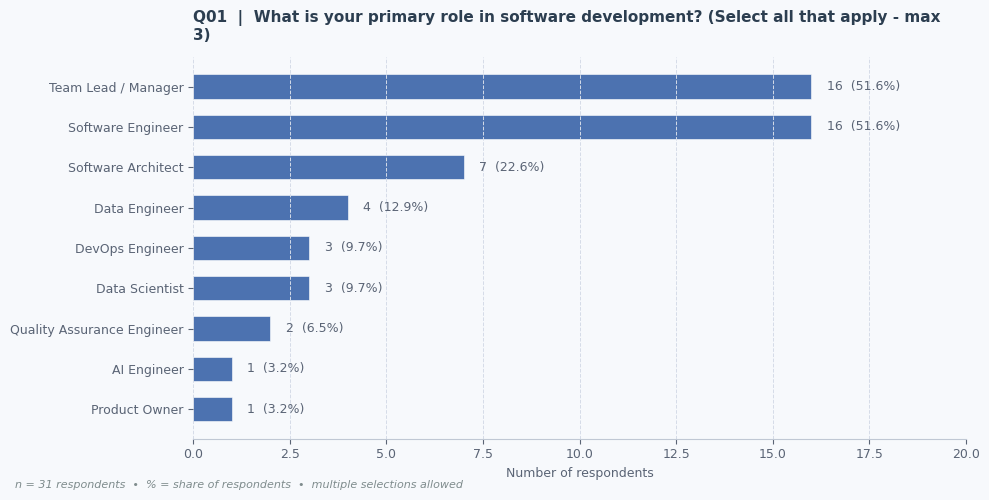


QQ02  |  How many years of experience do you have in software development? (Select one)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  4 - 6 years                                        7   22.6%   [11.4%, 39.8%]
  > 10 years                                        14   45.2%   [29.2%, 62.2%]
  7 - 10 years                                       4   12.9%    [5.1%, 28.9%]
  < 1 year                                           1    3.2%    [0.6%, 16.2%]
  1 - 3 years                                        5   16.1%    [7.1%, 32.6%]
──────────────────────────────────────────────────────────────────────────
  Dominant category : > 10 years
  Shannon entropy   : 1.9683 bits  (normalised: 0.8477)
  χ² (uniform)      : 15.2903,  p = 0.0041  —  ✓ significant at α = 0.05



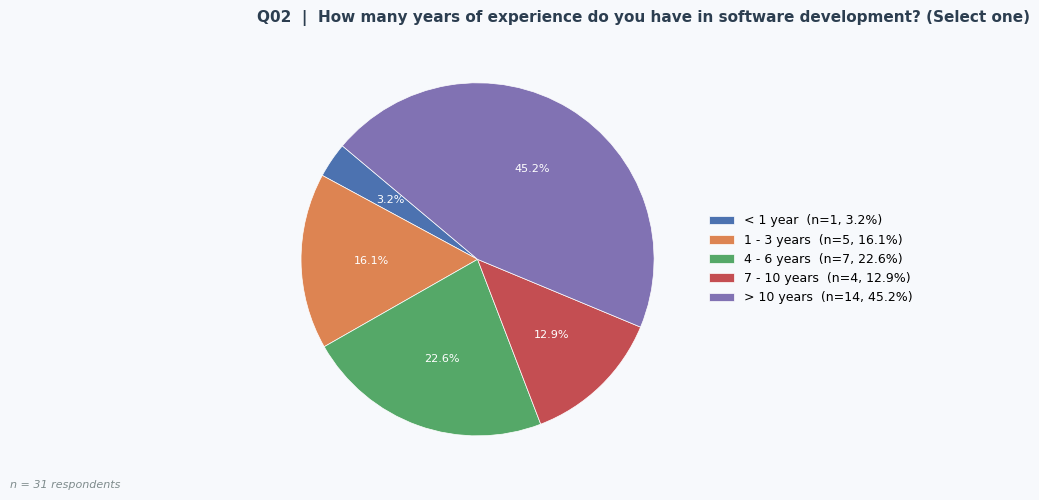


QQ03  |  How would you categorize the size of your organization? (Select one)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  Medium Business (51-100 employees)                 4   12.9%    [5.1%, 28.9%]
  Small (11-50 employees)                           13   41.9%   [26.4%, 59.2%]
  Large Enterprise (100+ employees)                 13   41.9%   [26.4%, 59.2%]
  Startup (1-10 employees)                           1    3.2%    [0.6%, 16.2%]
──────────────────────────────────────────────────────────────────────────
  Dominant category : Small (11-50 employees)
  Shannon entropy   : 1.5925 bits  (normalised: 0.7963)
  χ² (uniform)      : 14.8065,  p = 0.0020  —  ✓ significant at α = 0.05



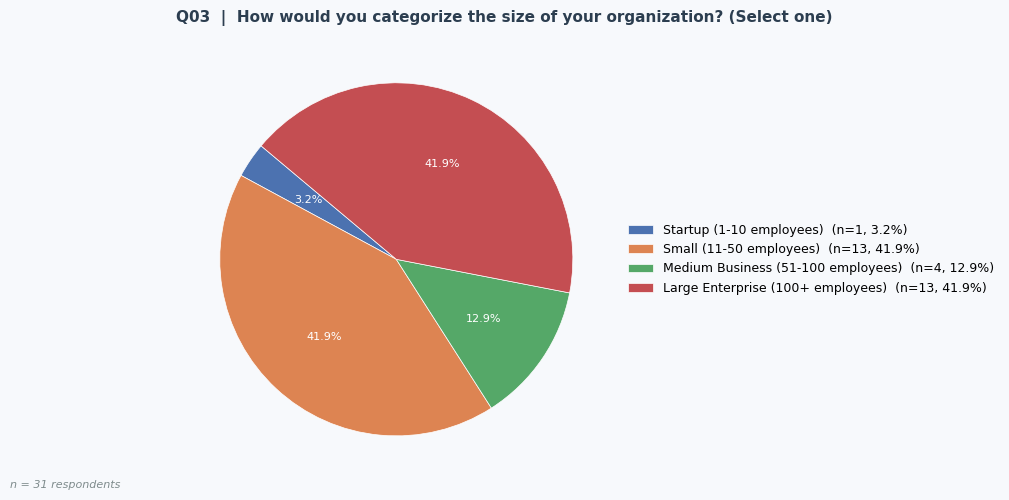


QQ04  |  What programming languages do you use primarily? (Select all that apply)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  Python                                            11   35.5%   [21.1%, 53.1%]
  C#                                                18   58.1%   [40.8%, 73.6%]
  TypeScript                                        14   45.2%   [29.2%, 62.2%]
  JavaScript                                        11   35.5%   [21.1%, 53.1%]
  PHP                                                2    6.5%    [1.8%, 20.7%]
  C / C++                                            1    3.2%    [0.6%, 16.2%]
  OutSystems                                         1    3.2%    [0.6%, 16.2%]
  Java                                               4   12.9%    [5.1%, 28.9%]
  PowerShell, SQL                              

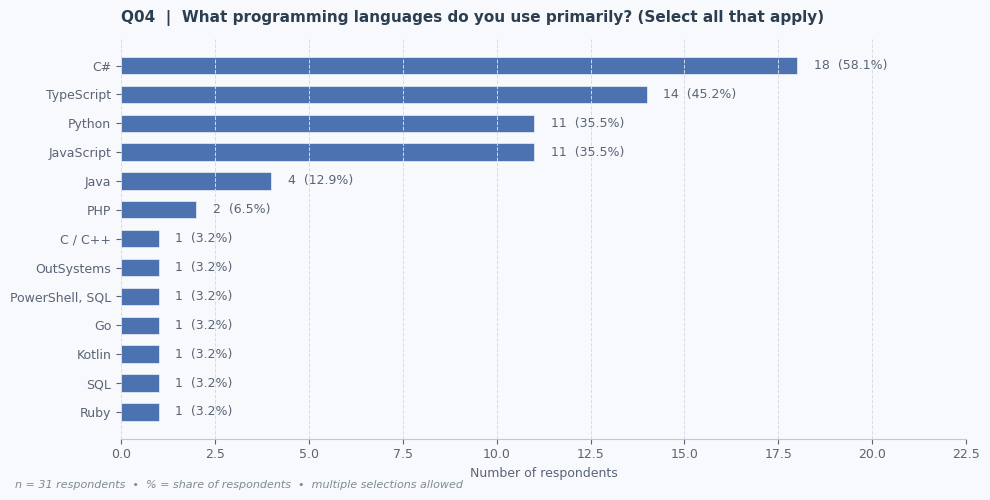


QQ05  |  What is the highest level of education you have completed in the Dutch education system? (Select one)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  WO (wetenschappelijk onderwijs – Research University)     12   38.7%   [23.7%, 56.2%]
  HBO (Hoger beroepsnderwijs – University of Applied Sciences)     19   61.3%   [43.8%, 76.3%]
──────────────────────────────────────────────────────────────────────────
  Dominant category : HBO (Hoger beroepsnderwijs – University of Applied Sciences)
  Shannon entropy   : 0.9629 bits  (normalised: 0.9629)
  χ² (uniform)      : 1.5806,  p = 0.2087  —  ✗ not significant at α = 0.05



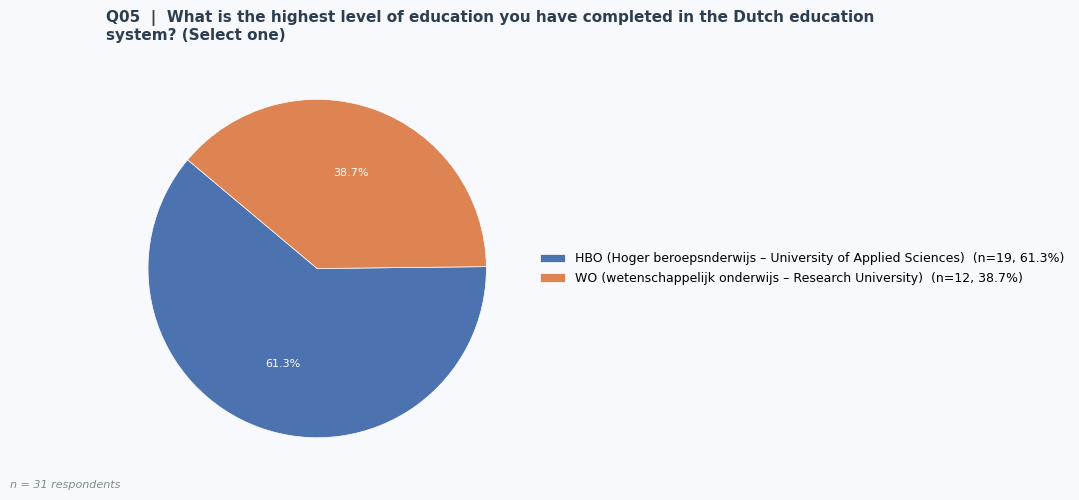


QQ06  |  What is your highest academic qualification? (Select one)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  PhD (Doctorate)                                    4   12.9%    [5.1%, 28.9%]
  Bachelor’s degree (BSc, BA, etc.)                 21   67.7%   [50.1%, 81.4%]
  Master’s degree (MSc, MA, etc.)                    5   16.1%    [7.1%, 32.6%]
  Associate degree                                   1    3.2%    [0.6%, 16.2%]
──────────────────────────────────────────────────────────────────────────
  Dominant category : Bachelor’s degree (BSc, BA, etc.)
  Shannon entropy   : 1.3462 bits  (normalised: 0.6731)
  χ² (uniform)      : 31.3226,  p = 0.0000  —  ✓ significant at α = 0.05



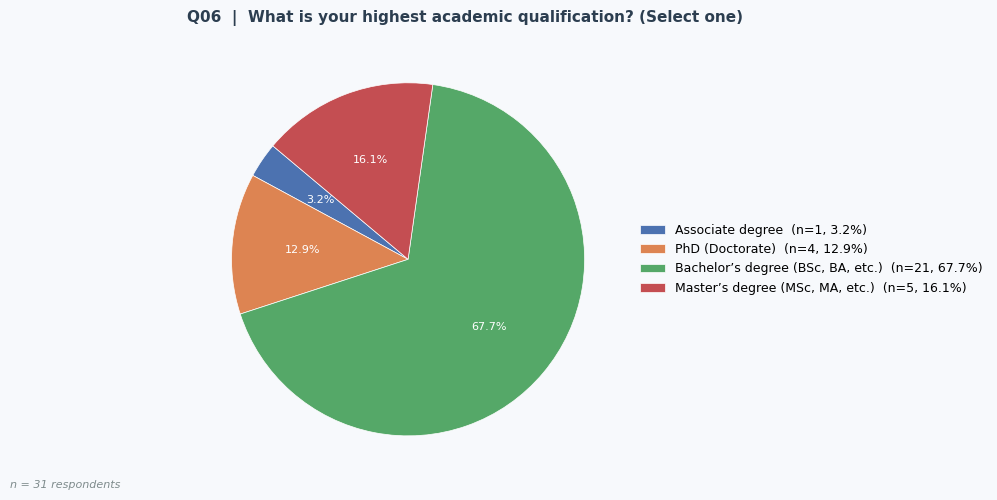


QQ07  |  How would you describe your organization's stance on the use of AI-assisted coding tools (e.g., ChatGPT, Copilot, Bard, Code Llama, CodeWhisperer, etc.)? Select the option that best reflects your ...
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  actively encourages the use of AI coding tools.     15   48.4%   [32.0%, 65.2%]
  allows the use of AI tools, but does not actively promote them.     16   51.6%   [34.8%, 68.0%]
──────────────────────────────────────────────────────────────────────────
  Dominant category : allows the use of AI tools, but does not actively promote them.
  Shannon entropy   : 0.9992 bits  (normalised: 0.9992)
  χ² (uniform)      : 0.0323,  p = 0.8575  —  ✗ not significant at α = 0.05



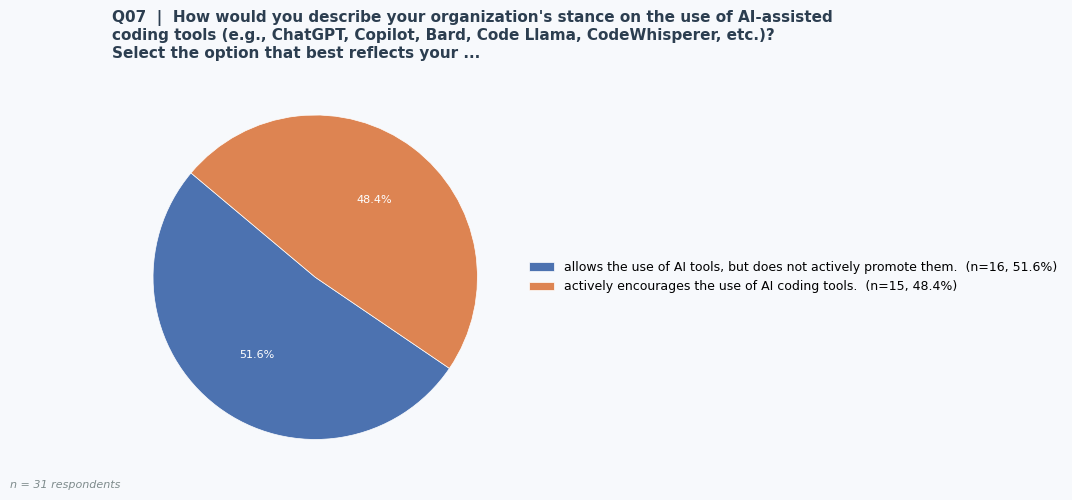


QQ08  |  How frequently do you use generative AI tools (e.g., ChatGPT, Copilot, Bard, Code Llama) in your workflow? (Select one)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  Regularly (daily or almost daily)                 26   83.9%   [67.4%, 92.9%]
  Occasionally (a few times a week)                  2    6.5%    [1.8%, 20.7%]
  Rarely (a few times a month)                       3    9.7%    [3.3%, 24.9%]
──────────────────────────────────────────────────────────────────────────
  Dominant category : Regularly (daily or almost daily)
  Shannon entropy   : 0.7940 bits  (normalised: 0.5010)
  χ² (uniform)      : 35.6774,  p = 0.0000  —  ✓ significant at α = 0.05



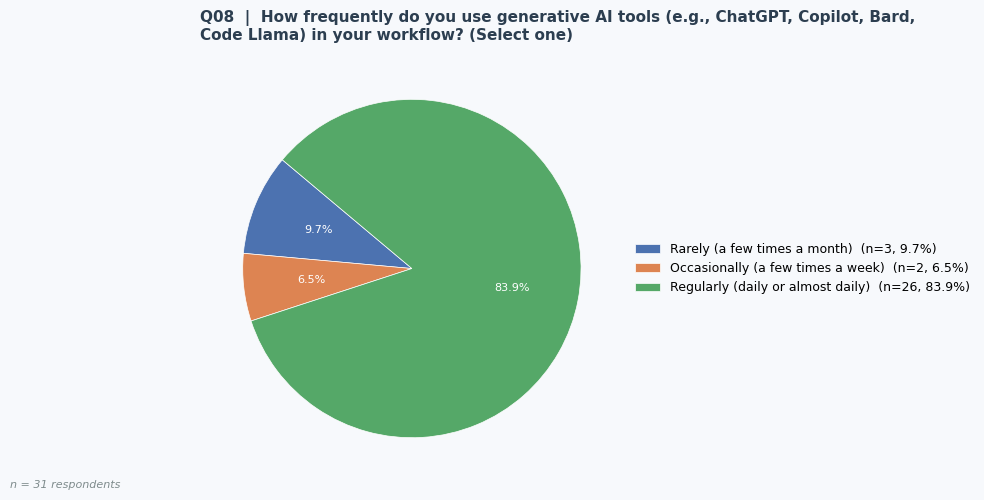


QQ09  |  For which tasks do you use generative AI? (Select all that apply)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  Debugging / Error Explanation                     22   71.0%   [53.4%, 83.9%]
  Code Review                                       11   35.5%   [21.1%, 53.1%]
  Brainstorming                                     25   80.6%   [63.7%, 90.8%]
  Code generation / auto-completion                 23   74.2%   [56.8%, 86.3%]
  Refactoring existing code                         13   41.9%   [26.4%, 59.2%]
  Test / Test case generation                       15   48.4%   [32.0%, 65.2%]
  Code Documentation                                14   45.2%   [29.2%, 62.2%]
  Self-development and Learning                     14   45.2%   [29.2%, 62.2%]
  Security Analysis                                  6

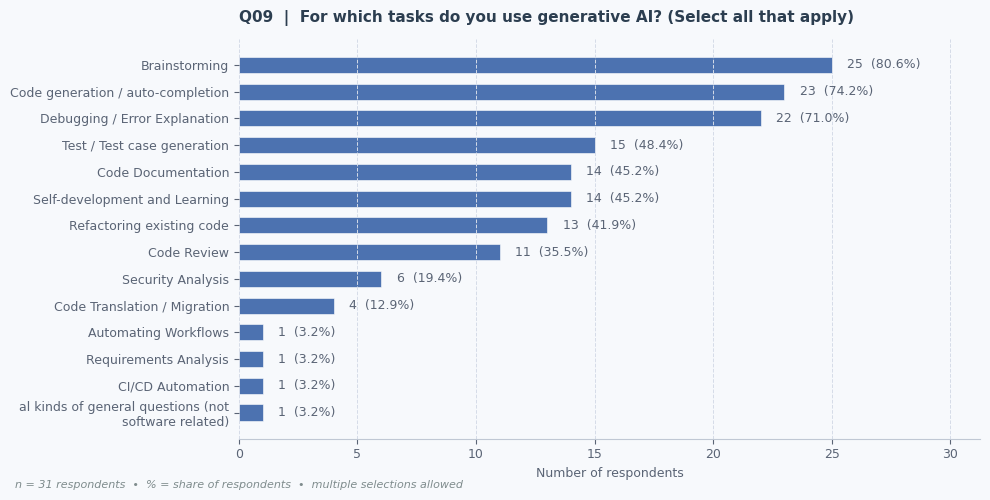


QQ10  |  How useful do you find generative AI is for the following tasks. (Please rate each from: Not Useful - Somewhat Useful - Very Useful - Essential - Not Applicable)
──────────────────────────────────────────────────────────────────────────
  Item: Brainstorming
    Not Useful                     :    1  (3.2%)
    Somewhat Useful                :    9  (29.0%)
    Very Useful                    :   16  (51.6%)
    Essential                      :    5  (16.1%)
    N/A count : 0
    Positive% : 67.7%  | Dominant: Very Useful
    Mean: 2.806  Median: 3.0  Std: 0.749
    Entropy: 1.5949 bits  (norm: 0.7974)
--------------------------------------------------------------------------
  Item: Self-development and Learning
    Not Useful                     :    1  (3.6%)
    Somewhat Useful                :   10  (35.7%)
    Very Useful                    :   16  (57.1%)
    Essential                      :    1  (3.6%)
    N/A count : 2
    Positive% : 60.7%  | Dominant: Very Useful
 

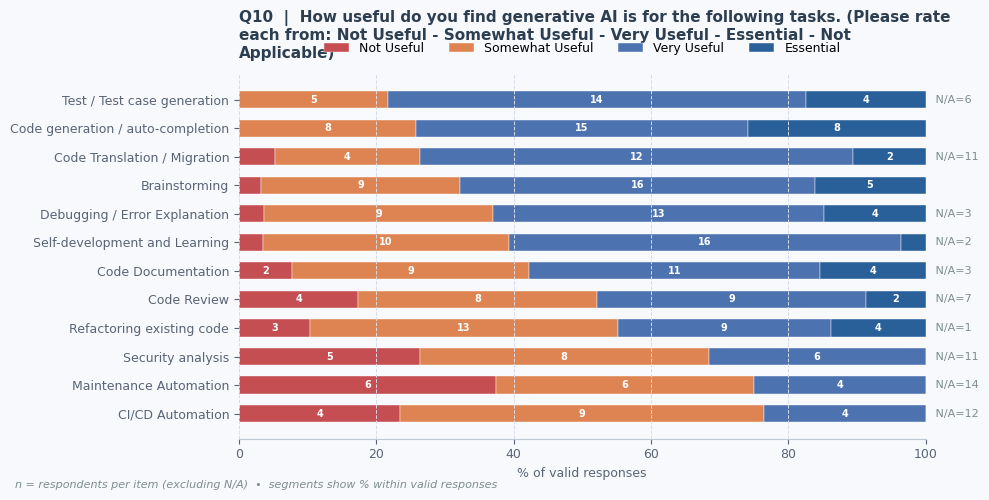


QQ11  |  Have you experienced any of the following common issues when using generative AI? (Select all that apply)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  Legal or licensing concerns                       11   35.5%   [21.1%, 53.1%]
  Difficulty in debugging AI-generated code         14   45.2%   [29.2%, 62.2%]
  AI-generated code did not follow the provided specification (prompt)     26   83.9%   [67.4%, 92.9%]
  Security vulnerabilities in AI-generated code     17   54.8%   [37.8%, 70.8%]
  Logic / Algorithmic error in AI-generated code     25   80.6%   [63.7%, 90.8%]
  where does my data go                              1    3.2%    [0.6%, 16.2%]
  Difficulty in CHANGING specifics on AI generated code      1    3.2%    [0.6%, 16.2%]
  Writing the right prompt                           1    3.2%

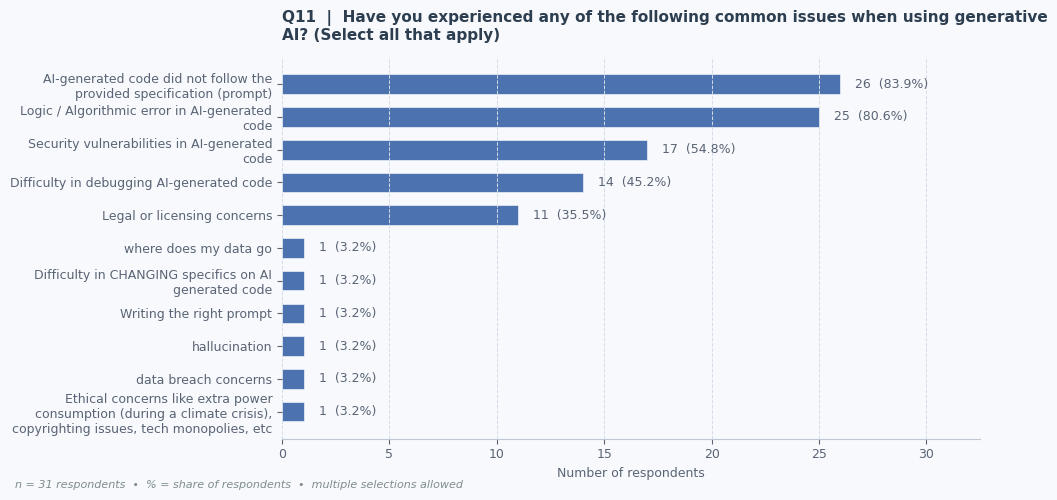


QQ12  |  In your opinion, what percentage of software developer's work will involve AI assistance in 5 years? (Select one)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  41 % - 60 %                                       10   32.3%   [18.6%, 49.9%]
  61 % - 80 %                                        9   29.0%   [16.1%, 46.6%]
  More than 80 %                                     8   25.8%   [13.7%, 43.2%]
  21% - 40%                                          4   12.9%    [5.1%, 28.9%]
──────────────────────────────────────────────────────────────────────────
  Dominant category : 41 % - 60 %
  Shannon entropy   : 1.9300 bits  (normalised: 0.9650)
  χ² (uniform)      : 2.6774,  p = 0.4441  —  ✗ not significant at α = 0.05



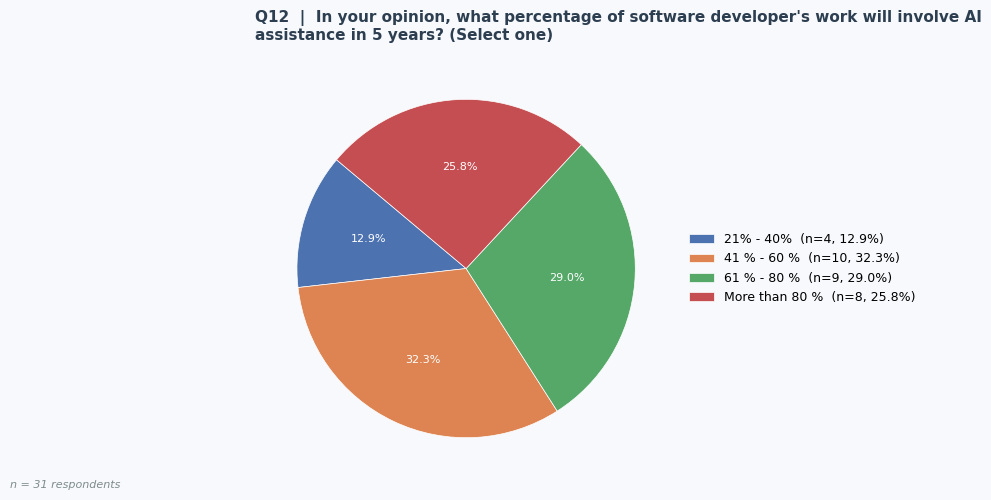


QQ13  |  In which phases of the software development life cycle do you anticipate generative AI will take over most human responsibilities within the next 3–5 years? (Select up to 3)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  Documentation                                     17   56.7%   [39.2%, 72.6%]
  Code writing                                      15   50.0%   [33.2%, 66.8%]
  Testing and quality assurance                     10   33.3%   [19.2%, 51.2%]
  ALL OF THE ABOVE                                   1    3.3%    [0.6%, 16.7%]
  Requirements analysis                              5   16.7%    [7.3%, 33.6%]
  Project management                                 4   13.3%    [5.3%, 29.7%]
  Debugging and issue resolution                    11   36.7%   [21.9%, 54.5%]
  Deployment and DevOps   

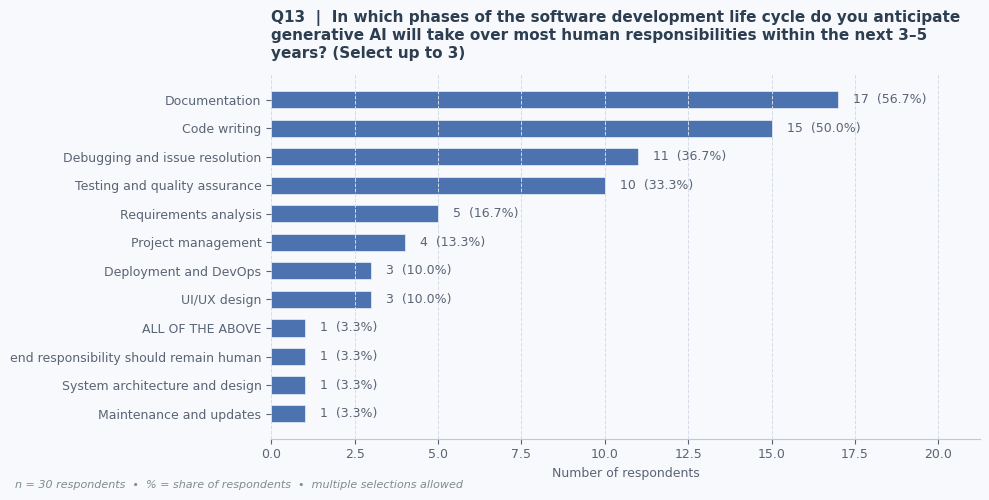


QQ14  |  Please rate how the importance of each skill is expected to change for future software developers in the context of AI-assisted software development. (Please rate each from: Decreasing, No Change, Slightly Increasing, Strongly Increasing)
──────────────────────────────────────────────────────────────────────────
  Item: Fundamental Concepts
    Decreasing in Importance       :    1  (3.7%)
    No Change                      :    4  (14.8%)
    Slightly Increasing            :    8  (29.6%)
    Strongly Increasing            :   14  (51.9%)
    N/A count : 0
    Positive% : 81.5%  | Dominant: Strongly Increasing
    Mean: 3.296  Median: 4.0  Std: 0.869
    Entropy: 1.5955 bits  (norm: 0.7978)
--------------------------------------------------------------------------
  Item: Reviewing and interpreting AI-generated code logic
    Decreasing in Importance       :    1  (3.4%)
    No Change                      :    2  (6.9%)
    Slightly Increasing            :   11  (37.9%)
    

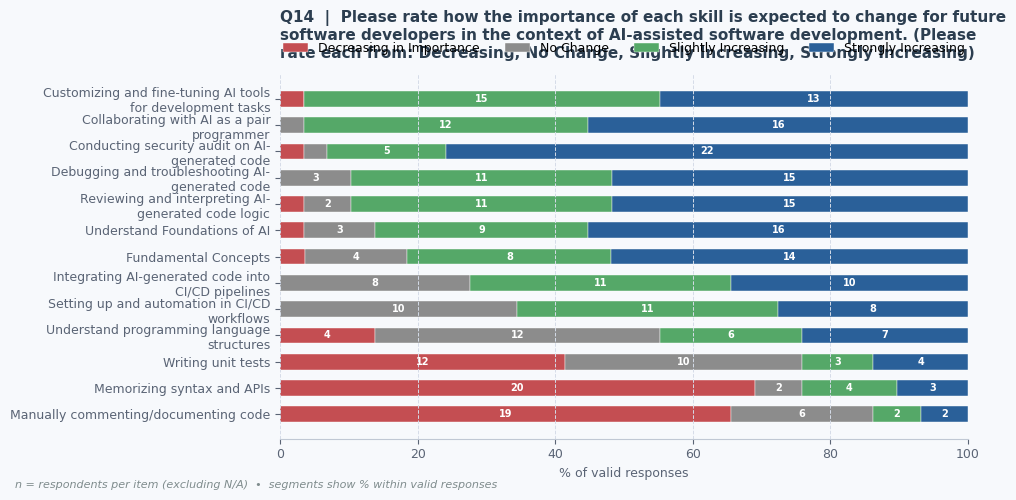


QQ16  |  Which skills will be most essential for future software developers in an AI-assisted development environment? (Select up to 3)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  Fundamentals of AI and Machine Learning (e.g., model concepts, training, data handling)      6   20.7%    [9.8%, 38.4%]
  Critical thinking and code review skills          23   79.3%   [61.6%, 90.2%]
  Understanding and/or Designing complex algorithms      5   17.2%    [7.6%, 34.5%]
  Secure coding and ethical AI awareness             8   27.6%   [14.7%, 45.7%]
  Effective prompt engineering for AI tools         10   34.5%   [19.9%, 52.7%]
  Continuous learning and adaptability               6   20.7%    [9.8%, 38.4%]
  Understanding limitations of AI-generated code     17   58.6%   [40.7%, 74.5%]
  System design and archit

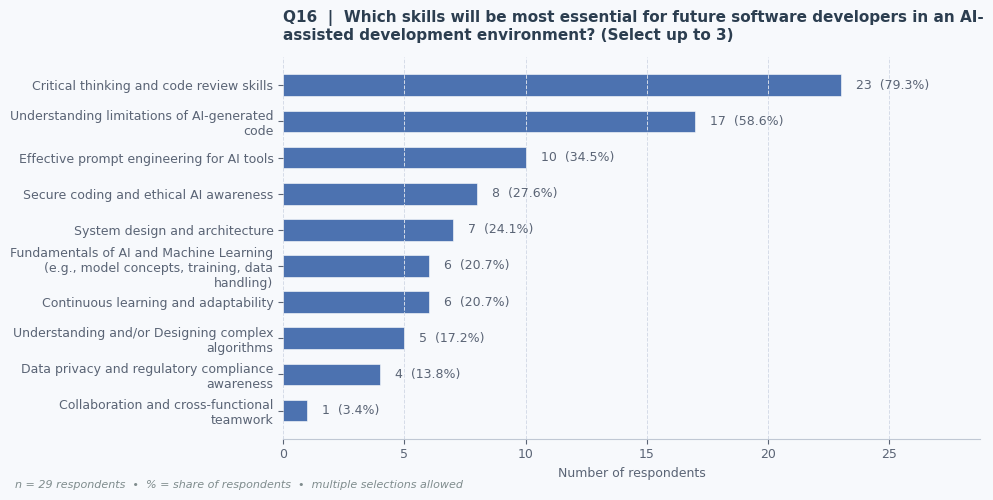


QQ17  |  What are the main challenges you foresee in the near future of AI-assisted software development? (Select all that apply)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  Security and data privacy risks                   21   72.4%   [54.3%, 85.3%]
  Accumulation of technical debt due to low-quality or rushed AI-generated code     18   62.1%   [44.0%, 77.3%]
  Compliance with industry-specific regulations (e.g., healthcare, finance, security)      7   24.1%   [12.2%, 42.1%]
  Lack of trust in AI-generated code                11   37.9%   [22.7%, 56.0%]
  Hallucinations or factual inaccuracies in AI suggestions     15   51.7%   [34.4%, 68.6%]
  Developer de-skilling or over-reliance on AI assistance     20   69.0%   [50.8%, 82.7%]
  Cost and accessibility of AI tools                 7   24.1%   [12

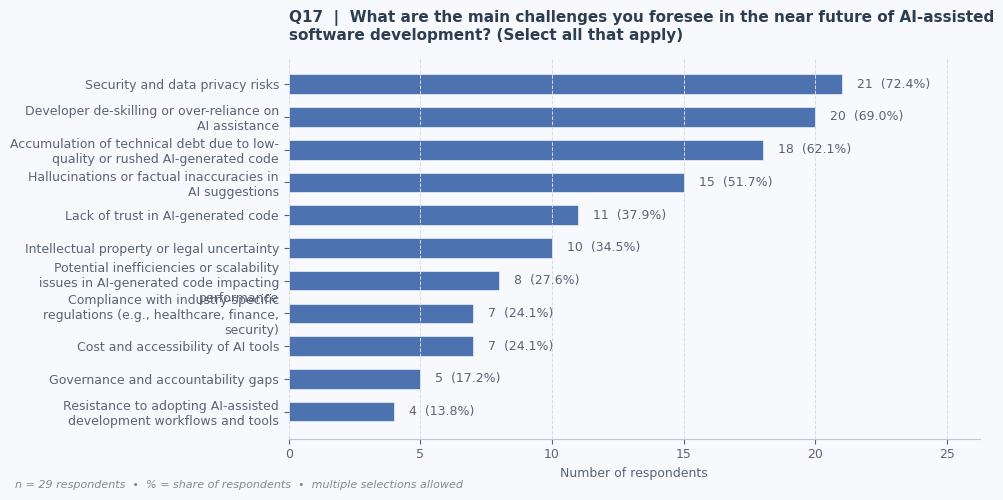


QQ18  |  How much do you trust AI-generated code without human review? (Select one)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  Not at all                                        16   55.2%   [37.5%, 71.6%]
  Somewhat                                          11   37.9%   [22.7%, 56.0%]
  Mostly                                             2    6.9%    [1.9%, 22.0%]
──────────────────────────────────────────────────────────────────────────
  Dominant category : Not at all
  Shannon entropy   : 1.2699 bits  (normalised: 0.8012)
  χ² (uniform)      : 10.4138,  p = 0.0055  —  ✓ significant at α = 0.05



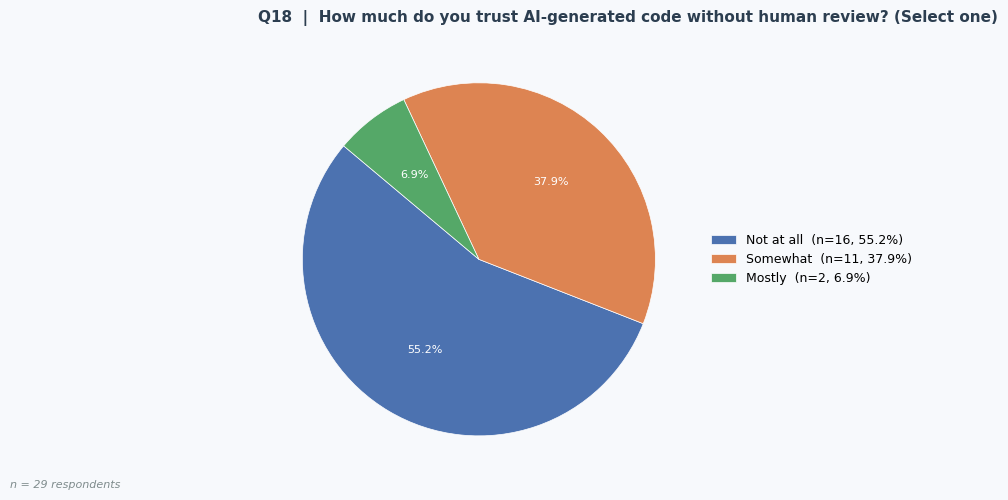


QQ19  |  Do you think AI-assisted development will replace traditional development roles? (Select one)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  It will create new roles and shift existing ones     11   37.9%   [22.7%, 56.0%]
  There will be changes, but software development will remain human-centered.     15   51.7%   [34.4%, 68.6%]
  It will not replace traditional development roles      2    6.9%    [1.9%, 22.0%]
  It will significantly reduce the need for developers      1    3.4%    [0.6%, 17.2%]
──────────────────────────────────────────────────────────────────────────
  Dominant category : There will be changes, but software development will remain human-centered.
  Shannon entropy   : 1.4560 bits  (normalised: 0.7280)
  χ² (uniform)      : 19.4138,  p = 0.0002  —  ✓ significant at α = 0.05


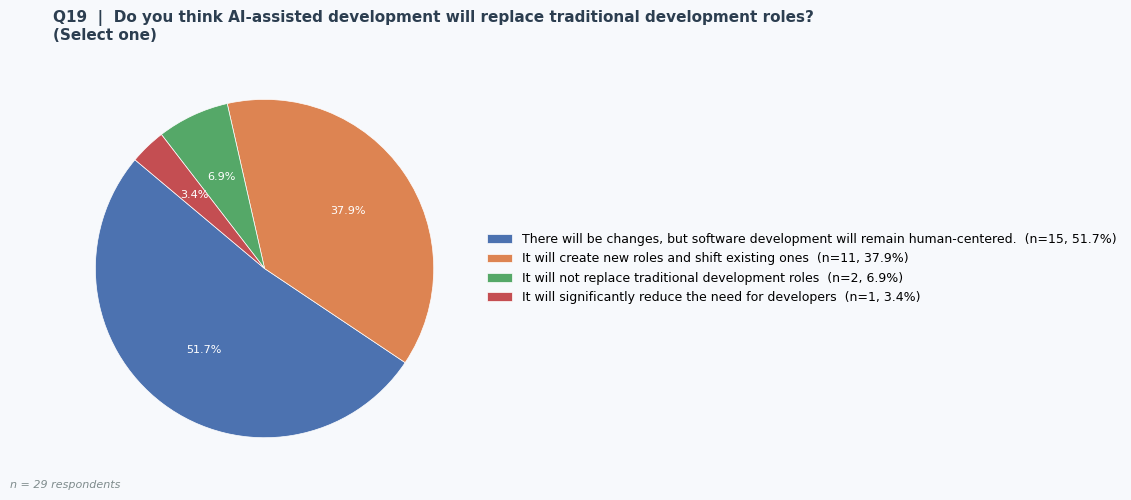


QQ20  |  How do you believe AI-assisted development affects the learning curve for junior developers? (Select one)
──────────────────────────────────────────────────────────────────────────
  Category                                           n       %           95% CI
--------------------------------------------------------------------------
  Reduces opportunities to learn core problem-solving skills     21   72.4%   [54.3%, 85.3%]
  No significant effect                              2    6.9%    [1.9%, 22.0%]
  They will work at a different level of abstraction, deep inner workings will become more obfuscated and less comprehensible.      1    3.4%    [0.6%, 17.2%]
  Much harder for juniors to get a foothold as part of your work is checking and guiding AI results, which requires experience      1    3.4%    [0.6%, 17.2%]
  Accelerates learning and skill acquisition         2    6.9%    [1.9%, 22.0%]
  Considering AI can be used as a learning assistant, I think it highly depends on 

/var/folders/wj/clr9h64d72jb58tcbvgn7zcw0000gn/T/ipykernel_78437/4097823362.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


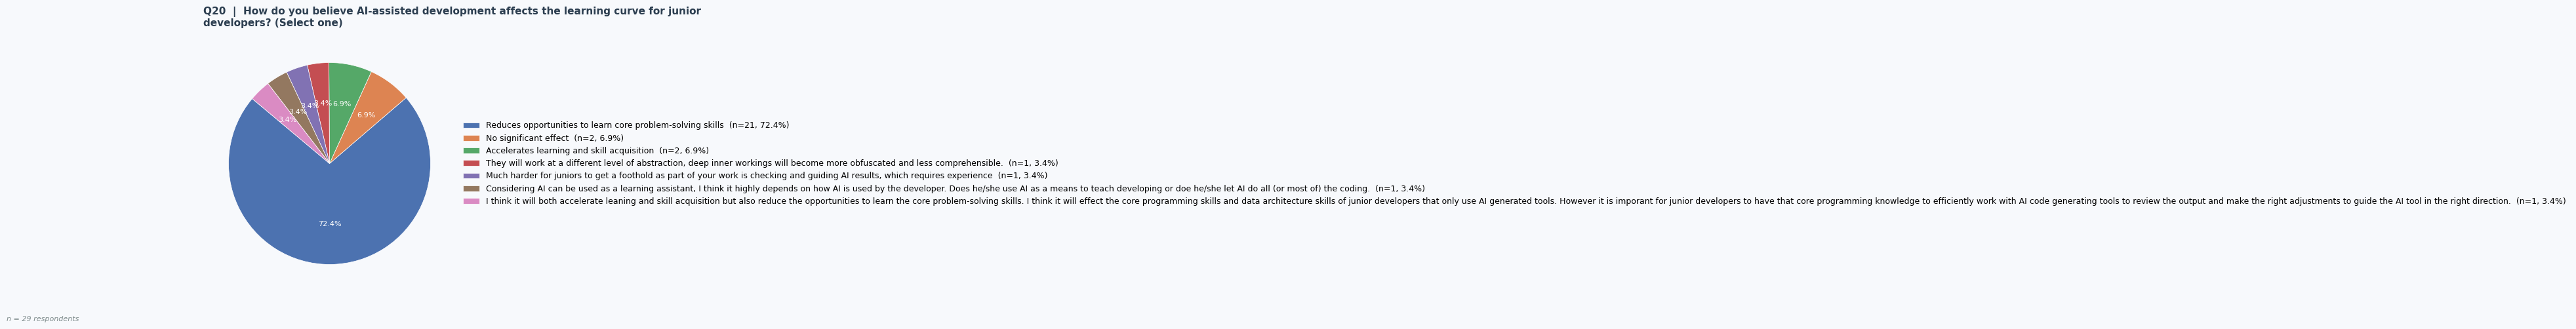


Q21  |  In your opinion, what is the greatest risk of relying heavily on AI-generated code? (Open-ended response)
  [Qualitative open-ended responses — see raw data output]

Q22  |  If AI-assisted development tools become mainstream, how do you think the hiring process / requirements for developers will change? (Open-ended text response)
  [Qualitative open-ended responses — see raw data output]

Q23  |  Do you have any additional comments or insights about the use AI in software development? (Open-ended text response)

  [Qualitative open-ended responses — see raw data output]
Exported: ./output/statistical_analysis.md — 22 questions processed


In [15]:
# Cell 15 — Export Statistical Analysis: Print, Visualise, and Export to Markdown

import os

def export_stats_report(sheets, output_path="./output/statistical_analysis.md"):
    """For every question: print stats, render chart inline, build Markdown, write file."""
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    md_sections = []
    n_processed = 0

    for qid, meta in QUESTION_REGISTRY.items():
        q_type = meta["type"]
        label  = meta["label"]
        scale  = meta.get("scale")
        sheet  = sheets.get(qid)
        if sheet is None:
            continue

        q_text = str(sheet.iloc[0, 1]) if q_type != "scaling" else str(sheet.iloc[0, 1] if sheet.shape[1] > 1 else qid)

        # Step 1 — Print statistical report
        if q_type != "open":
            results = analyse_question(sheets, qid, q_type, scale=scale, print_report=True, return_results=True)
        else:
            print(f"\n{qid}  |  {q_text}")
            print("  [Qualitative open-ended responses — see raw data output]")
            results = None

        # Step 2 — Render visualisation inline (no double-print of stats)
        if q_type != "open":
            show_question(sheets, qid, print_stats=False)

        # Step 3 — Build Markdown section
        if q_type != "scaling":
            n_resp = len(_get_responses(qid)) if q_type != "open" else "N/A"
        else:
            df_sc  = get_scaling_question(qid)
            n_resp = len(df_sc)

        md = [f"## {qid} \u2014 {label}",
              "",
              f"**Type:** {q_type}",
              f"**Question:** {q_text}",
              f"**Respondents:** {n_resp}",
              "",
              "### Distribution",
              ""]

        if q_type == "open":
            md.append("*Qualitative responses \u2014 see raw data output above.*")

        elif q_type in ("single", "multi") and results:
            md.append("| Category | n | % | 95% CI (Wilson) |")
            md.append("|---|---|---|---|")
            for cat, n, pct, (lo, hi) in zip(
                    results["categories"], results["counts"],
                    results["pcts"],       results["wilson_cis"]):
                md.append(f"| {cat} | {n} | {pct*100:.1f}% | [{lo*100:.1f}%, {hi*100:.1f}%] |")
            md += ["", "### Key Statistics", ""]
            md.append(f"- **Dominant category:** {results['dominant']}")
            ent_b, ent_n = results["entropy"]
            md.append(f"- **Shannon entropy:** {ent_b:.4f} bits (normalised: {ent_n:.4f} \u2014 0 = full consensus, 1 = uniform)")
            chi2, p = results["chi2"]
            if chi2 is not None:
                sig = "\u2713 significant" if p < 0.05 else "\u2717 not significant"
                md.append(f"- **\u03c7\u00b2 (uniform):** {chi2:.4f}, p = {p:.4f} \u2014 {sig} at \u03b1 = 0.05")

        elif q_type == "scaling" and results:
            md.append("| Item | Mean | Median | Std | 95% CI | Positive% | Dominant | Entropy | N/A |")
            md.append("|---|---|---|---|---|---|---|---|---|")
            for ir in results["items"]:
                s     = ir["stats"]
                ci_lo = round(s["mean_ci_95"][0], 3)
                ci_hi = round(s["mean_ci_95"][1], 3)
                ent_b, _ = ir["entropy"]
                md.append(
                    f"| {ir['item']} | {s['mean']:.3f} | {s['median']:.1f} | {s['std']:.3f} "
                    f"| [{ci_lo}, {ci_hi}] | {ir['positive_pct']*100:.1f}% "
                    f"| {ir['dominant']} | {ent_b:.4f} | {ir['na_count']} |"
                )
            md += ["", "### Key Statistics", ""]
            sc_order = scale["order"] if scale else []
            md.append(f"- **Scale:** {' \u2192 '.join(sc_order)}")
            if results["items"]:
                by_mean   = sorted(results["items"], key=lambda r: r["stats"]["mean"] if not np.isnan(r["stats"]["mean"]) else 0)
                highest   = by_mean[-1]
                lowest    = by_mean[0]
                md.append(f"- **Highest-priority item:** {highest['item']} "
                          f"(mean {highest['stats']['mean']:.2f}, {highest['positive_pct']*100:.0f}% positive)")
                md.append(f"- **Lowest-priority item:** {lowest['item']} "
                          f"(mean {lowest['stats']['mean']:.2f}, {lowest['positive_pct']*100:.0f}% positive)")
                if len(sc_order) >= 4:
                    top_lbl  = sc_order[-1]
                    bot_lbl  = sc_order[0]
                    top_items = [r["item"] for r in results["items"] if r["dominant"] == top_lbl]
                    bot_items = [r["item"] for r in results["items"] if r["dominant"] == bot_lbl]
                    md.append(f"- **Items with '{top_lbl}' dominant:** {', '.join(top_items) or 'none'}")
                    md.append(f"- **Items with '{bot_lbl}' dominant:** {', '.join(bot_items) or 'none'}")

        md_sections.append("\n".join(md))
        n_processed += 1

    full_md = (
        "# Statistical Analysis Report\n"
        "## Survey: Software Engineering in the Era of Generative AI\n\n"
        + "\n\n---\n\n".join(md_sections)
    )

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(full_md)

    print(f"Exported: {output_path} \u2014 {n_processed} questions processed")


export_stats_report(SHEETS)

---
## Usage Examples

```python
# Single question — full output
show_question(SHEETS, 'Q08')

# Multi-choice question, top 10 items
show_question(SHEETS, 'Q09', top_n=10)

# Scaling question
show_question(SHEETS, 'Q10')

# Open-ended
show_question(SHEETS, 'Q21')

# Cross-analyses
cross_q03_q09(SHEETS, size_groups)
cross_q03_q10(SHEETS, size_groups, scale=SCALE_USEFULNESS)
cross_q03_q11(SHEETS, size_groups)
cross_q05_q14(SHEETS, edu_groups, scale=SCALE_IMPORTANCE_CHANGE)
cross_q05_q16(SHEETS, edu_groups)

# Save a chart
show_question(SHEETS, 'Q16', save_path='./output/Q16_essential_skills.png')
```